# Trabalho 08 — Separação de canais em imagens coloridas
## Isolamento por zeramento (mínimo) e por maximização

**Disciplina:** Computação Gráfica / Processamento de Imagens Digitais
**Professor:** André Alessandro Stein
**Aluno:** Igor
**Instituição:** IFC — Campus Rio do Sul

### Enunciado

> **a)** Efetuar separação de cores entre os valores RGB (**mínimo**) na imagem
> original (P3):
> - Imagem 1 → manter R, zerar G e B
> - Imagem 2 → manter G, zerar R e B
> - Imagem 3 → manter B, zerar R e G
>
> **b)** Efetuar separação de cores entre os valores RGB (**máximo**) na imagem
> original (P3):
> - Imagem 4 → manter R, levar G e B a 255
> - Imagem 5 → manter G, levar R e B a 255
> - Imagem 6 → manter B, levar R e G a 255

### Observação sobre o formato de saída

O título da atividade menciona PGM, mas as operações descritas preservam as três
componentes de cada píxel e produzem imagens coloridas. As seis saídas são
portanto **PPM P3**, mesmo formato da entrada.

### As duas propriedades que serão demonstradas

Este notebook não se limita a gerar os seis arquivos. As duas famílias de
separação satisfazem relações algébricas exatas com a imagem original, e
verificá-las é a melhor evidência de que a implementação está correta:

| Item | Relação |
|------|---------|
| (a) | `Imagem1 + Imagem2 + Imagem3 = Original` |
| (b) | `mín(Imagem4, Imagem5, Imagem6) = Original` |

A primeira é uma decomposição **aditiva**; a segunda, seu dual **subtrativo**.

### Referências

- STEIN, A. A.; HECK, C. *Processamento de Imagens Digitais* — slides da disciplina.
- LOPES, J. M. Brisson. *Formatos de Imagem*. DEI — IST, Lisboa, 2003 (reed. 2013).

## 1. Fundamentação

### Síntese aditiva e cores secundárias

Os slides da disciplina apresentam o RGB como modelo de **síntese aditiva**: todo
objeto que emite luz visível é percebido em função da soma das cores espectrais
emitidas, e a combinação das primárias duas a duas, em igual intensidade, produz
as secundárias.

| Primárias combinadas | Secundária resultante |
|----------------------|-----------------------|
| Vermelho + Verde | Amarelo |
| Vermelho + Azul | Magenta |
| Verde + Azul | Ciano |

Essa tabela é o que explica a aparência das imagens do item (b), como se verá
adiante.

### Item (a) — isolamento por zeramento

Manter um canal e zerar os outros dois equivale a **projetar** cada píxel sobre
um dos eixos do cubo RGB. A imagem resultante contém somente luz daquela
primária.

Como cada imagem carrega um canal e zeros nas demais posições, somar as três
recompõe o píxel original componente a componente:

    (R,0,0) + (0,G,0) + (0,0,B) = (R,G,B)

Não há aproximação nem perda: é uma decomposição exata. Cada arquivo isolado
perde informação, mas o **conjunto** dos três preserva tudo.

Um efeito colateral previsível: as três imagens são escuras. Dois terços das
componentes de cada píxel foram anulados, de modo que a média de intensidade de
cada uma fica em torno de um terço da média original — e as três médias somadas
devolvem exatamente a média original.

### Item (b) — isolamento por maximização

Manter um canal e levar os outros dois ao máximo é a operação complementar.
Onde o canal preservado vale 0, as duas componentes maximizadas produzem
justamente a **cor secundária** correspondente:

| Imagem | Canal mantido | Canais em 255 | Cor quando o canal vale 0 |
|--------|---------------|---------------|---------------------------|
| 4 | R | G, B | Ciano |
| 5 | G | R, B | Magenta |
| 6 | B | R, G | Amarelo |

Conforme o canal preservado cresce em direção a 255, o píxel caminha da
secundária até o branco. Cada imagem é assim uma rampa de uma cor secundária ao
branco, o que dá a essas saídas uma aparência "lavada", de alta claridade.

A relação com a original também é exata, mas por outra operação. Para a
componente R, por exemplo: a Imagem 4 guarda R, enquanto as Imagens 5 e 6 têm R
em 255. O **mínimo** entre as três recupera R — e o mesmo vale para G e B.

In [1]:
# Bibliotecas e configuração

import textwrap
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

BASE = Path.cwd()
ENTRADA = BASE / "entrada"
SAIDA = BASE / "saida"
SAIDA.mkdir(exist_ok=True)

NOME_IMAGEM = "Fig4.ppm"
ARQUIVO_ENTRADA = ENTRADA / NOME_IMAGEM

LIMITE_COLUNA = 70
CANAIS = ("R", "G", "B")
NOMES_CANAIS = ("Vermelho", "Verde", "Azul")

print(f"Entrada existe : {ARQUIVO_ENTRADA.exists()}")
print(f"Arquivo        : {ARQUIVO_ENTRADA.name}")

Entrada existe : True
Arquivo        : Fig4.ppm


In [2]:
# --- Leitor e escritor PPM P3 ---

def _fluxo_tokens(arquivo):
    """Gera tokens do arquivo, descartando comentários iniciados por '#'."""
    for linha in arquivo:
        util = linha.split("#", 1)[0]
        for token in util.split():
            yield token


def ler_ppm_p3(caminho):
    """Lê um PPM tipo P3 e devolve (matriz (altura, largura, 3), maxval)."""
    with open(caminho, "r", encoding="ascii") as f:
        it = _fluxo_tokens(f)

        magic = next(it)
        if magic != "P3":
            raise ValueError(f"Magic number inesperado: {magic!r} (esperado 'P3')")

        largura, altura, maxval = (int(next(it)) for _ in range(3))
        esperados = largura * altura * 3
        dados = np.fromiter(map(int, it), dtype=np.int32, count=esperados)

    if dados.size != esperados:
        raise ValueError(f"Esperados {esperados} valores, lidos {dados.size}")

    return dados.reshape(altura, largura, 3), maxval


def escrever_ppm_p3(caminho, imagem, maxval, comentario=None,
                    limite_coluna=LIMITE_COLUNA):
    """Grava uma matriz (altura, largura, 3) como PPM tipo P3."""
    imagem = np.asarray(imagem)
    if imagem.ndim != 3 or imagem.shape[2] != 3:
        raise ValueError(f"Esperado shape (altura, largura, 3), recebido {imagem.shape}")
    if imagem.min() < 0 or imagem.max() > maxval:
        raise ValueError(f"Valores fora do intervalo [0, {maxval}]")

    altura, largura, _ = imagem.shape

    # Múltiplo de 3 para manter píxeis RGB inteiros por linha
    n = max(1, (limite_coluna + 1) // (len(str(maxval)) + 1))
    n = max(3, n - (n % 3))

    plano = imagem.reshape(-1).tolist()

    with open(caminho, "w", encoding="ascii", newline="\n") as f:
        f.write("P3\n")
        if comentario:
            for trecho in textwrap.wrap(comentario, width=limite_coluna - 2):
                f.write(f"# {trecho}\n")
        f.write(f"{largura} {altura}\n")
        f.write(f"{maxval}\n")
        linhas = [" ".join(map(str, plano[i:i + n]))
                  for i in range(0, len(plano), n)]
        f.write("\n".join(linhas))
        f.write("\n")

    return caminho


def verificar_limite_colunas(caminho, limite=LIMITE_COLUNA):
    maior = 0
    with open(caminho, "r", encoding="ascii") as f:
        for numero, linha in enumerate(f, start=1):
            comprimento = len(linha.rstrip("\n"))
            if comprimento > limite:
                raise AssertionError(f"Linha {numero}: {comprimento} caracteres")
            maior = max(maior, comprimento)
    return maior

IMAGEM ORIGINAL
------------------------------------------------------
Arquivo          : Fig4.ppm
Dimensões        : 481 x 321
Total de píxeis  : 154,401
maxval           : 255
Média global     : 85.04

Canal          Mín   Máx     Média    Desvio
--------------------------------------------
Vermelho         1   255     87.56     59.23
Verde           19   213     83.64     34.78
Azul             0   235     83.91     52.24


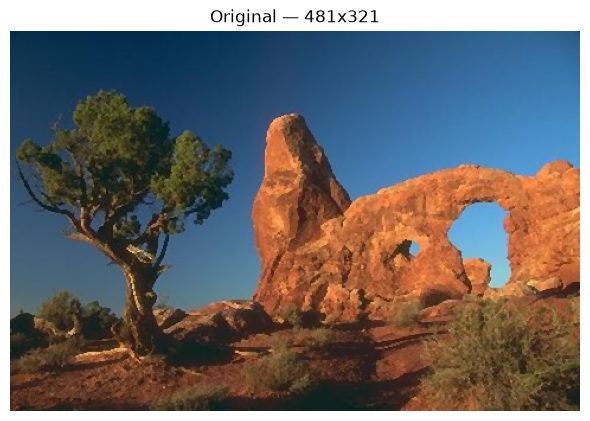

In [3]:
# --- Leitura e caracterização da entrada ---

original, MAXVAL = ler_ppm_p3(ARQUIVO_ENTRADA)
altura, largura, _ = original.shape

print("IMAGEM ORIGINAL")
print("-" * 54)
print(f"Arquivo          : {ARQUIVO_ENTRADA.name}")
print(f"Dimensões        : {largura} x {altura}")
print(f"Total de píxeis  : {largura * altura:,}")
print(f"maxval           : {MAXVAL}")
print(f"Média global     : {original.mean():.2f}")
print()
print(f"{'Canal':<12}{'Mín':>6}{'Máx':>6}{'Média':>10}{'Desvio':>10}")
print("-" * 44)
for i, nome in enumerate(NOMES_CANAIS):
    c = original[:, :, i]
    print(f"{nome:<12}{c.min():>6}{c.max():>6}{c.mean():>10.2f}{c.std():>10.2f}")

plt.figure(figsize=(6, 5))
plt.imshow(original / MAXVAL)
plt.title(f"Original — {largura}x{altura}")
plt.axis("off")
plt.tight_layout()
plt.show()

---

## Item (a) — Separação por zeramento

Para cada canal `c`, constrói-se uma imagem em que apenas `c` conserva seus
valores e os outros dois ficam em zero.

### Nota de implementação

Um cuidado que evita um bug sutil: partir de `np.zeros_like(original)` cria um
array **novo**, e atribuir o canal a ele copia os valores. Escrever
`img = original` seguido de `img[:, :, 1] = 0` não criaria cópia alguma — as duas
variáveis apontariam para o mesmo array, e a imagem original seria destruída no
processo.

Esse tipo de aliasing é uma das armadilhas mais comuns com NumPy, porque não
gera erro: o programa segue rodando com dados corrompidos.

In [4]:
# --- Item (a): construção das três imagens ---

def isolar_zerando(imagem, canal):
    """
    Mantém o canal indicado e zera os outros dois.

    Parte de um array de zeros novo — nunca de uma referência à imagem
    original — para não modificar a entrada por aliasing.
    """
    saida = np.zeros_like(imagem)
    saida[:, :, canal] = imagem[:, :, canal]
    return saida


imagens_a = [isolar_zerando(original, c) for c in range(3)]

# Confirma que a original permaneceu intacta
assert original.max() > 0 and original.mean() > 0

print(f"{'Imagem':<10}{'Canal':<10}{'Média':>10}{'Mín':>7}{'Máx':>7}")
print("-" * 46)
for i, (img, nome) in enumerate(zip(imagens_a, NOMES_CANAIS), start=1):
    print(f"{'Imagem ' + str(i):<10}{nome:<10}{img.mean():>10.2f}"
          f"{img.max(axis=(0,1))[i-1]:>7}{img[:, :, i-1].max():>7}")

print()
print(f"Média da original        : {original.mean():.2f}")
print(f"Soma das três médias     : {sum(im.mean() for im in imagens_a):.2f}")
print()
print("As médias somam exatamente a da original — primeiro indício de que a")
print("decomposição é aditiva e exata.")

Imagem    Canal          Média    Mín    Máx
----------------------------------------------
Imagem 1  Vermelho       29.19    255    255
Imagem 2  Verde          27.88    213    213
Imagem 3  Azul           27.97    235    235

Média da original        : 85.04
Soma das três médias     : 85.04

As médias somam exatamente a da original — primeiro indício de que a
decomposição é aditiva e exata.


In [5]:
# --- Item (a): verificação da propriedade aditiva ---

soma = imagens_a[0] + imagens_a[1] + imagens_a[2]

assert np.array_equal(soma, original), "A soma das três imagens não reproduz a original!"

print("PROPRIEDADE ADITIVA CONFIRMADA")
print("-" * 54)
print("Imagem1 + Imagem2 + Imagem3 == Original  (elemento a elemento)")
print()
print(f"Píxeis divergentes : {int((soma != original).sum())}")
print(f"Diferença máxima   : {int(np.abs(soma - original).max())}")
print()
print("Nenhuma informação se perde no conjunto das três imagens: cada uma")
print("carrega um terço do conteúdo, e juntas recompõem a original sem")
print("qualquer aproximação.")

PROPRIEDADE ADITIVA CONFIRMADA
------------------------------------------------------
Imagem1 + Imagem2 + Imagem3 == Original  (elemento a elemento)

Píxeis divergentes : 0
Diferença máxima   : 0

Nenhuma informação se perde no conjunto das três imagens: cada uma
carrega um terço do conteúdo, e juntas recompõem a original sem
qualquer aproximação.


In [6]:
# --- Item (a): gravação dos três arquivos ---

arquivos_a = []
for i, (img, canal, nome) in enumerate(zip(imagens_a, CANAIS, NOMES_CANAIS), start=1):
    caminho = SAIDA / f"imagem{i}_{canal}_zerando_outros.ppm"
    zerados = [c for c in CANAIS if c != canal]

    escrever_ppm_p3(
        caminho, img, MAXVAL,
        comentario=(f"item (a) - imagem {i} - mantem canal {canal} ({nome}) e "
                    f"zera {' e '.join(zerados)} - origem {ARQUIVO_ENTRADA.name}")
    )

    lida, mv = ler_ppm_p3(caminho)
    assert mv == MAXVAL and np.array_equal(lida, img)
    arquivos_a.append(caminho)

    print(f"Imagem {i} ({canal}) -> {caminho.name}")
    print(f"   round-trip OK | maior linha: {verificar_limite_colunas(caminho)} | "
          f"{caminho.stat().st_size / 1024**2:.2f} MB")

Imagem 1 (R) -> imagem1_R_zerando_outros.ppm
   round-trip OK | maior linha: 64 | 1.07 MB
Imagem 2 (G) -> imagem2_G_zerando_outros.ppm
   round-trip OK | maior linha: 68 | 1.08 MB
Imagem 3 (B) -> imagem3_B_zerando_outros.ppm
   round-trip OK | maior linha: 67 | 1.08 MB


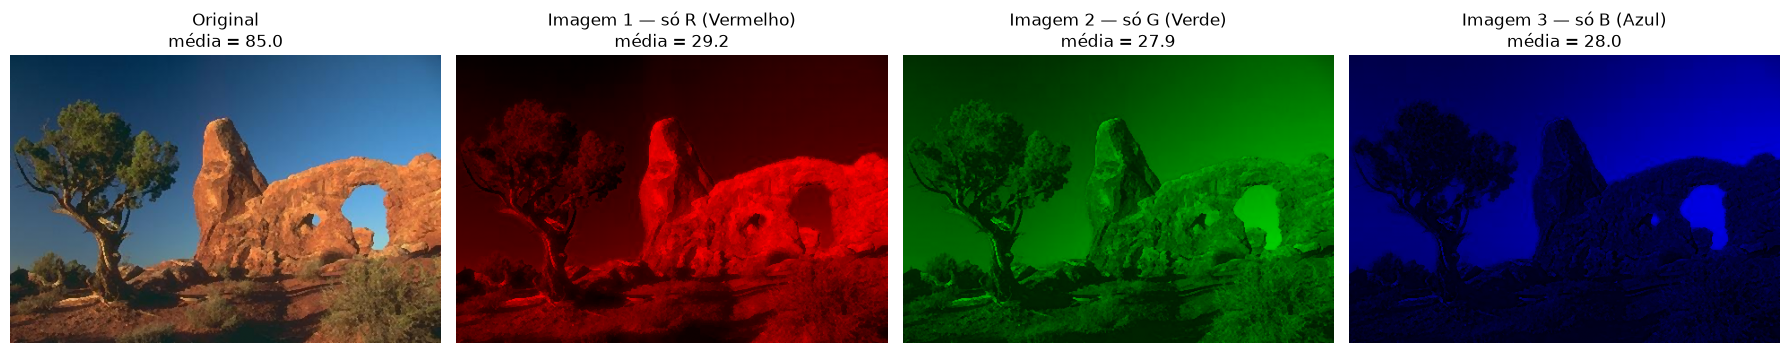

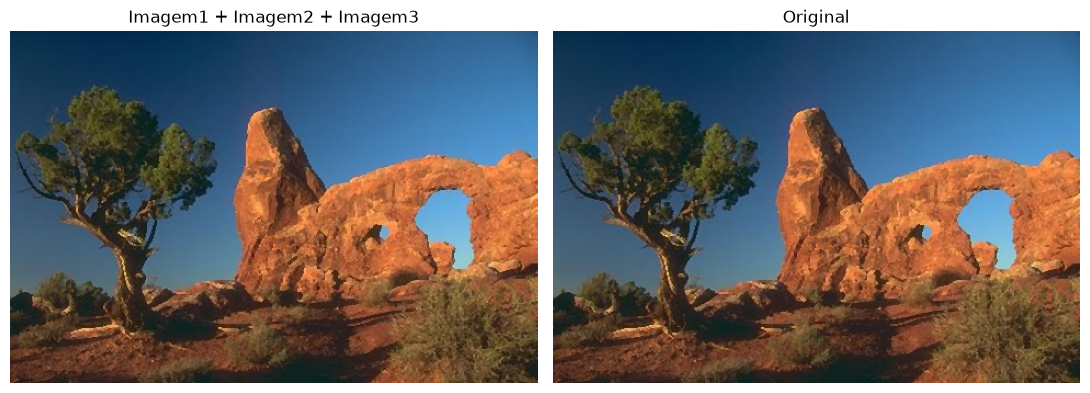

As três imagens são escuras porque cada uma conserva apenas uma das três
componentes de luz. Somadas, reconstituem a imagem colorida completa.


In [7]:
# --- Item (a): visualização ---

fig, eixos = plt.subplots(1, 4, figsize=(18, 4.5))

eixos[0].imshow(original / MAXVAL)
eixos[0].set_title(f"Original\nmédia = {original.mean():.1f}")

for i, (img, canal, nome) in enumerate(zip(imagens_a, CANAIS, NOMES_CANAIS), start=1):
    eixos[i].imshow(img / MAXVAL)
    eixos[i].set_title(f"Imagem {i} — só {canal} ({nome})\nmédia = {img.mean():.1f}")

for ax in eixos:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Demonstração visual da recomposição
fig, eixos = plt.subplots(1, 2, figsize=(11, 5))
eixos[0].imshow(soma / MAXVAL)
eixos[0].set_title("Imagem1 + Imagem2 + Imagem3")
eixos[1].imshow(original / MAXVAL)
eixos[1].set_title("Original")
for ax in eixos:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("As três imagens são escuras porque cada uma conserva apenas uma das três")
print("componentes de luz. Somadas, reconstituem a imagem colorida completa.")

---

## Item (b) — Separação por maximização

Agora o canal escolhido é preservado e os outros dois vão a 255.

### O que se vê

Onde o canal preservado vale 0, restam apenas as duas componentes maximizadas —
e a cor resultante é a secundária correspondente, conforme a tabela dos slides.
Onde o canal preservado vale 255, todas as três estão no máximo e o píxel é
branco.

Cada imagem é assim uma rampa contínua entre uma cor secundária e o branco:

| Imagem | Canal mantido | Extremo escuro (canal = 0) | Extremo claro (canal = 255) |
|--------|---------------|---------------------------|-----------------------------|
| 4 | R | Ciano (0, 255, 255) | Branco |
| 5 | G | Magenta (255, 0, 255) | Branco |
| 6 | B | Amarelo (255, 255, 0) | Branco |

Note a inversão perceptual em relação ao item (a): ali, valores altos do canal
produziam mais luz daquela primária; aqui, valores **baixos** do canal produzem a
cor mais saturada, e valores altos levam ao branco. As imagens do item (b) são
claras, com médias bem acima da original.

### A relação com a original

Para recuperar a componente R de um píxel: a Imagem 4 a preserva, enquanto as
Imagens 5 e 6 têm R fixo em 255. Como qualquer valor de R é menor ou igual a 255,
o **mínimo** entre as três devolve o valor original. O mesmo argumento vale para
G e B, o que torna a operação de mínimo o análogo subtrativo da soma do item (a).

In [8]:
# --- Item (b): construção das três imagens ---

def isolar_maximizando(imagem, canal, maxval=MAXVAL):
    """Mantém o canal indicado e leva os outros dois ao valor máximo."""
    saida = np.full_like(imagem, maxval)
    saida[:, :, canal] = imagem[:, :, canal]
    return saida


imagens_b = [isolar_maximizando(original, c) for c in range(3)]

secundarias = {0: "Ciano", 1: "Magenta", 2: "Amarelo"}

print(f"{'Imagem':<10}{'Canal':<10}{'Média':>10}   cor quando o canal vale 0")
print("-" * 62)
for i, (img, nome) in enumerate(zip(imagens_b, NOMES_CANAIS), start=4):
    c = i - 4
    cor = [0 if j == c else MAXVAL for j in range(3)]
    print(f"{'Imagem ' + str(i):<10}{nome:<10}{img.mean():>10.2f}   "
          f"{secundarias[c]} {tuple(cor)}")

print()
print(f"Média da original : {original.mean():.2f}")
print("As três imagens têm média muito superior — dois terços das componentes")
print("de cada píxel foram levados ao máximo.")

Imagem    Canal          Média   cor quando o canal vale 0
--------------------------------------------------------------
Imagem 4  Vermelho      199.19   Ciano (0, 255, 255)
Imagem 5  Verde         197.88   Magenta (255, 0, 255)
Imagem 6  Azul          197.97   Amarelo (255, 255, 0)

Média da original : 85.04
As três imagens têm média muito superior — dois terços das componentes
de cada píxel foram levados ao máximo.


In [9]:
# --- Item (b): verificação da propriedade do mínimo ---

minimo = np.minimum(np.minimum(imagens_b[0], imagens_b[1]), imagens_b[2])

assert np.array_equal(minimo, original), "O mínimo das três não reproduz a original!"

print("PROPRIEDADE DO MÍNIMO CONFIRMADA")
print("-" * 54)
print("mín(Imagem4, Imagem5, Imagem6) == Original  (elemento a elemento)")
print()
print(f"Píxeis divergentes : {int((minimo != original).sum())}")
print(f"Diferença máxima   : {int(np.abs(minimo - original).max())}")
print()
print("Justificativa, tomando a componente R como exemplo:")
print(f"  Imagem 4 guarda R          -> valor entre 0 e {MAXVAL}")
print(f"  Imagens 5 e 6 têm R = {MAXVAL}")
print(f"  o mínimo entre os três é sempre o R original")
print()
print("É o dual subtrativo da soma do item (a): lá as imagens se acumulam,")
print("aqui elas se restringem mutuamente.")

PROPRIEDADE DO MÍNIMO CONFIRMADA
------------------------------------------------------
mín(Imagem4, Imagem5, Imagem6) == Original  (elemento a elemento)

Píxeis divergentes : 0
Diferença máxima   : 0

Justificativa, tomando a componente R como exemplo:
  Imagem 4 guarda R          -> valor entre 0 e 255
  Imagens 5 e 6 têm R = 255
  o mínimo entre os três é sempre o R original

É o dual subtrativo da soma do item (a): lá as imagens se acumulam,
aqui elas se restringem mutuamente.


In [10]:
# --- Item (b): gravação dos três arquivos ---

arquivos_b = []
for i, (img, canal, nome) in enumerate(zip(imagens_b, CANAIS, NOMES_CANAIS), start=4):
    caminho = SAIDA / f"imagem{i}_{canal}_maximizando_outros.ppm"
    maximizados = [c for c in CANAIS if c != canal]

    escrever_ppm_p3(
        caminho, img, MAXVAL,
        comentario=(f"item (b) - imagem {i} - mantem canal {canal} ({nome}) e "
                    f"leva {' e '.join(maximizados)} a {MAXVAL} - "
                    f"origem {ARQUIVO_ENTRADA.name}")
    )

    lida, mv = ler_ppm_p3(caminho)
    assert mv == MAXVAL and np.array_equal(lida, img)
    arquivos_b.append(caminho)

    print(f"Imagem {i} ({canal}) -> {caminho.name}")
    print(f"   round-trip OK | maior linha: {verificar_limite_colunas(caminho)} | "
          f"{caminho.stat().st_size / 1024**2:.2f} MB")

Imagem 4 (R) -> imagem4_R_maximizando_outros.ppm
   round-trip OK | maior linha: 70 | 1.66 MB
Imagem 5 (G) -> imagem5_G_maximizando_outros.ppm
   round-trip OK | maior linha: 67 | 1.67 MB
Imagem 6 (B) -> imagem6_B_maximizando_outros.ppm
   round-trip OK | maior linha: 66 | 1.67 MB


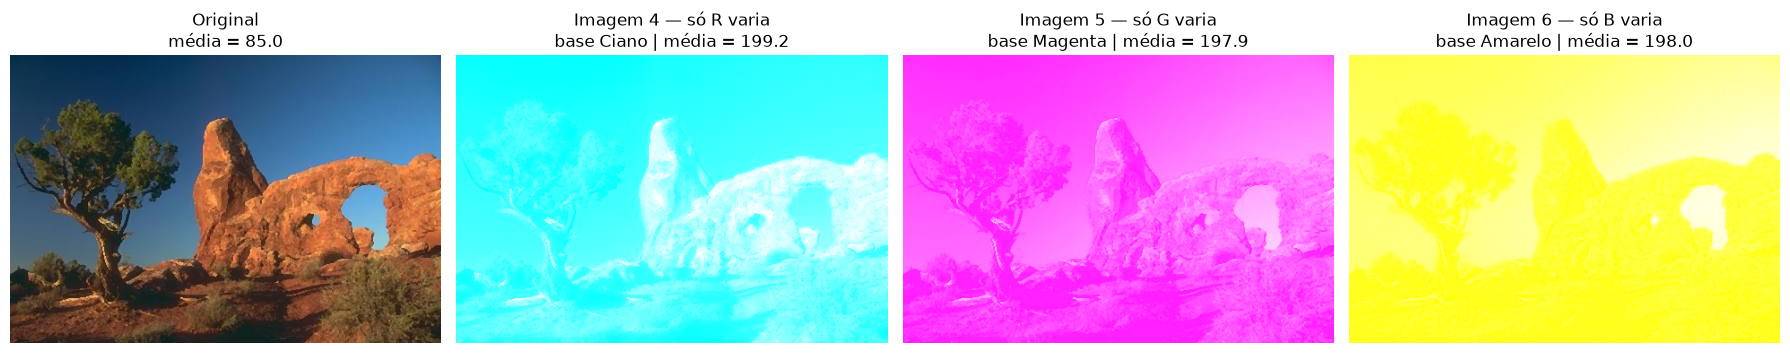

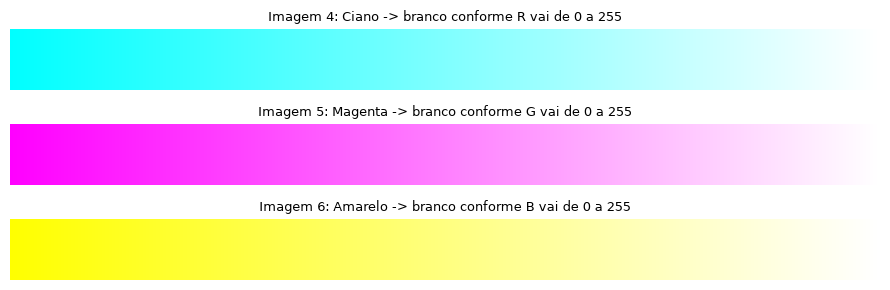

In [11]:
# --- Item (b): visualização ---

fig, eixos = plt.subplots(1, 4, figsize=(18, 4.5))

eixos[0].imshow(original / MAXVAL)
eixos[0].set_title(f"Original\nmédia = {original.mean():.1f}")

for i, (img, canal) in enumerate(zip(imagens_b, CANAIS), start=1):
    eixos[i].imshow(img / MAXVAL)
    eixos[i].set_title(f"Imagem {i + 3} — só {canal} varia\n"
                       f"base {secundarias[i - 1]} | média = {img.mean():.1f}")

for ax in eixos:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Rampas de cor de cada imagem do item (b)
fig, eixos = plt.subplots(3, 1, figsize=(9, 3))
rampa = np.linspace(0, MAXVAL, 256, dtype=np.int32)
for c, ax in enumerate(eixos):
    faixa = np.full((1, 256, 3), MAXVAL, dtype=np.int32)
    faixa[0, :, c] = rampa
    ax.imshow(np.repeat(faixa, 20, axis=0) / MAXVAL, aspect="auto")
    ax.set_title(f"Imagem {c + 4}: {secundarias[c]} -> branco conforme "
                 f"{CANAIS[c]} vai de 0 a {MAXVAL}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

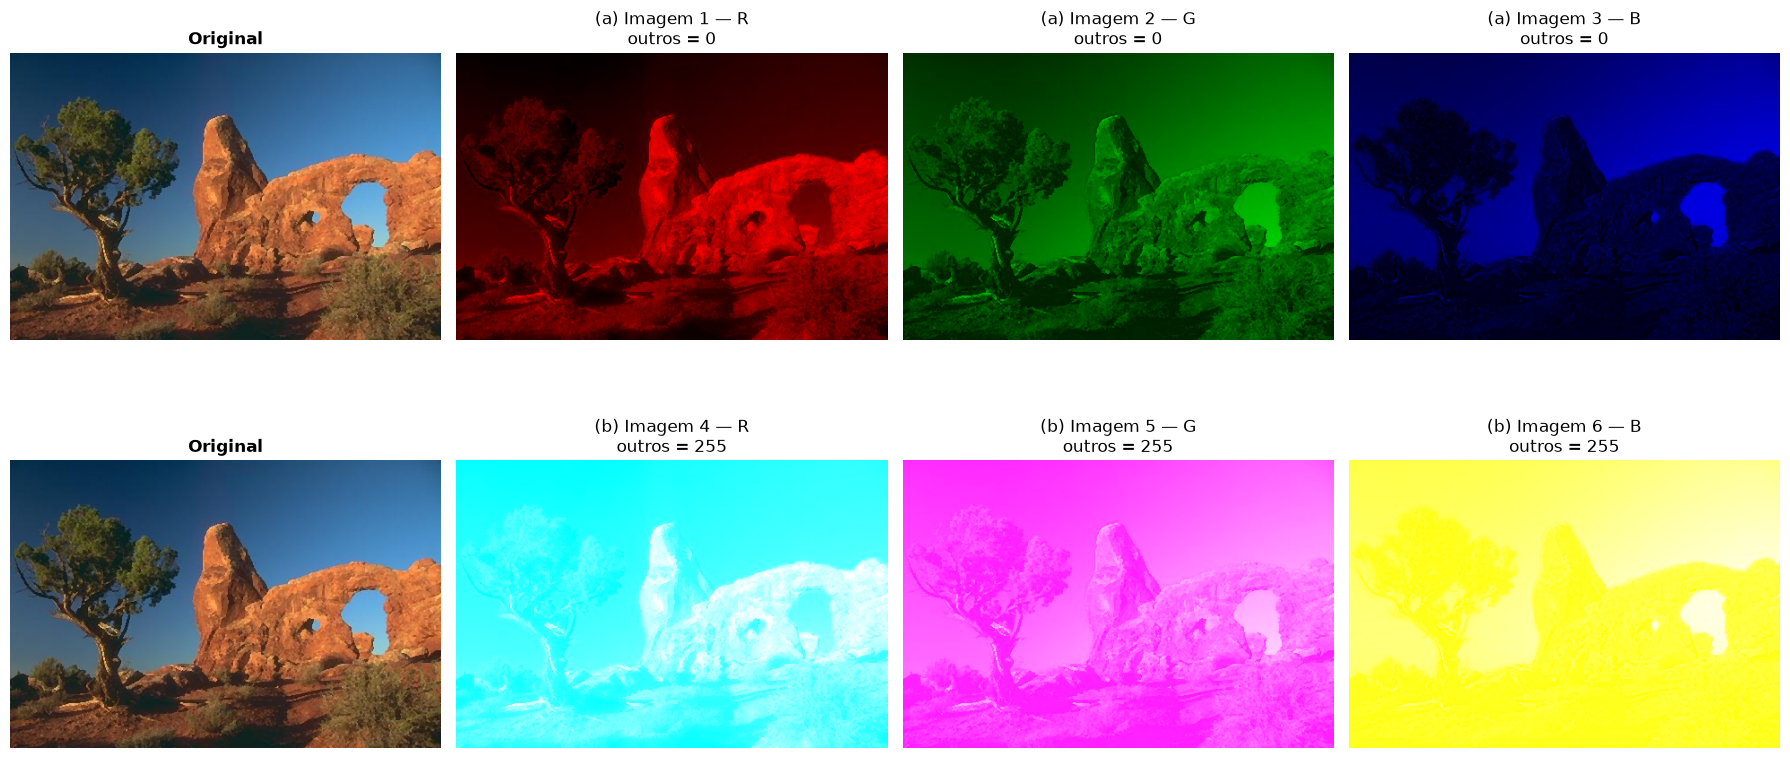

Linha superior: isolamento por zeramento — imagens escuras, nas cores
primárias, que somadas recompõem a original.
Linha inferior: isolamento por maximização — imagens claras, com base
nas cores secundárias, cujo mínimo recompõe a original.


In [12]:
# --- Painel completo: as seis saídas ---

fig, eixos = plt.subplots(2, 4, figsize=(18, 9))

eixos[0, 0].imshow(original / MAXVAL)
eixos[0, 0].set_title("Original", fontweight="bold")
eixos[1, 0].imshow(original / MAXVAL)
eixos[1, 0].set_title("Original", fontweight="bold")

for i, (img, canal) in enumerate(zip(imagens_a, CANAIS)):
    eixos[0, i + 1].imshow(img / MAXVAL)
    eixos[0, i + 1].set_title(f"(a) Imagem {i + 1} — {canal}\noutros = 0")

for i, (img, canal) in enumerate(zip(imagens_b, CANAIS)):
    eixos[1, i + 1].imshow(img / MAXVAL)
    eixos[1, i + 1].set_title(f"(b) Imagem {i + 4} — {canal}\noutros = {MAXVAL}")

for ax in eixos.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Linha superior: isolamento por zeramento — imagens escuras, nas cores")
print("primárias, que somadas recompõem a original.")
print("Linha inferior: isolamento por maximização — imagens claras, com base")
print("nas cores secundárias, cujo mínimo recompõe a original.")

RELAÇÃO ENTRE OS ITENS (a) E (b)
----------------------------------------------------------
Para cada canal c:
    255 - Imagem_max(c)  ==  Imagem_zero construída sobre (255 - canal c)

Verificado nos três canais. As duas famílias não são operações
independentes: uma é o negativo da outra aplicado ao canal complementado.


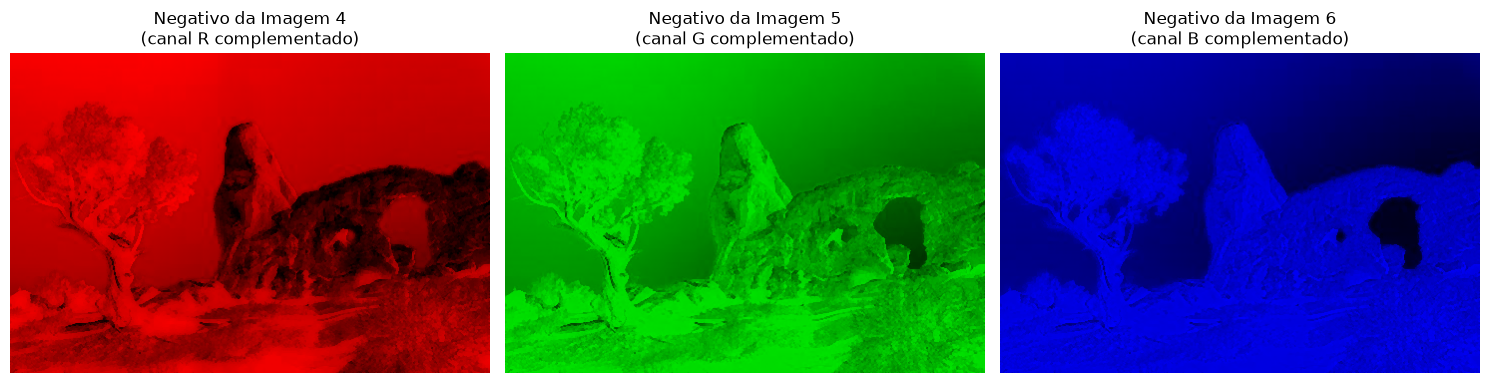

In [13]:
# --- Relação entre as duas famílias ---

# O negativo de uma imagem do item (b) é a imagem do item (a) construída
# sobre o negativo do canal correspondente.
for c, canal in enumerate(CANAIS):
    negativo_b = MAXVAL - imagens_b[c]
    esperado = np.zeros_like(original)
    esperado[:, :, c] = MAXVAL - original[:, :, c]
    assert np.array_equal(negativo_b, esperado), f"Relação falhou no canal {canal}"

print("RELAÇÃO ENTRE OS ITENS (a) E (b)")
print("-" * 58)
print("Para cada canal c:")
print(f"    {MAXVAL} - Imagem_max(c)  ==  Imagem_zero construída sobre "
      f"({MAXVAL} - canal c)")
print()
print("Verificado nos três canais. As duas famílias não são operações")
print("independentes: uma é o negativo da outra aplicado ao canal complementado.")

fig, eixos = plt.subplots(1, 3, figsize=(15, 4.5))
for c, canal in enumerate(CANAIS):
    eixos[c].imshow((MAXVAL - imagens_b[c]) / MAXVAL)
    eixos[c].set_title(f"Negativo da Imagem {c + 4}\n(canal {canal} complementado)")
    eixos[c].axis("off")
plt.tight_layout()
plt.show()

In [14]:
# --- Verificação final de todos os arquivos gerados ---

todos = [(f"Imagem {i}", p, img)
         for i, (p, img) in enumerate(zip(arquivos_a, imagens_a), start=1)]
todos += [(f"Imagem {i}", p, img)
          for i, (p, img) in enumerate(zip(arquivos_b, imagens_b), start=4)]

print(f"{'Saída':<10}{'Arquivo':<42}{'Magic':>7}{'Round-trip':>12}{'Col.':>7}")
print("-" * 78)

for rotulo, caminho, esperado in todos:
    with open(caminho) as f:
        magic = f.readline().strip()
    lida, _ = ler_ppm_p3(caminho)
    ok = "OK" if np.array_equal(lida, esperado) else "FALHOU"
    print(f"{rotulo:<10}{caminho.name:<42}{magic:>7}{ok:>12}"
          f"{verificar_limite_colunas(caminho):>7}")

print()
tam_total = sum(p.stat().st_size for _, p, _ in todos)
tam_orig = ARQUIVO_ENTRADA.stat().st_size
print(f"Tamanho da original      : {tam_orig / 1024**2:>7.2f} MB")
print(f"Soma das seis saídas     : {tam_total / 1024**2:>7.2f} MB")
print(f"Razão                    : {tam_total / tam_orig:>7.2f}x")

Saída     Arquivo                                     Magic  Round-trip   Col.
------------------------------------------------------------------------------
Imagem 1  imagem1_R_zerando_outros.ppm                   P3          OK     64
Imagem 2  imagem2_G_zerando_outros.ppm                   P3          OK     68
Imagem 3  imagem3_B_zerando_outros.ppm                   P3          OK     67
Imagem 4  imagem4_R_maximizando_outros.ppm               P3          OK     70
Imagem 5  imagem5_G_maximizando_outros.ppm               P3          OK     67
Imagem 6  imagem6_B_maximizando_outros.ppm               P3          OK     66

Tamanho da original      :    1.49 MB
Soma das seis saídas     :    8.24 MB
Razão                    :    5.54x


---

## Conclusões

### Arquivos gerados

| Item | Imagem | Arquivo | Operação |
|------|--------|---------|----------|
| (a) | 1 | `imagem1_R_zerando_outros.ppm` | mantém R, zera G e B |
| (a) | 2 | `imagem2_G_zerando_outros.ppm` | mantém G, zera R e B |
| (a) | 3 | `imagem3_B_zerando_outros.ppm` | mantém B, zera R e G |
| (b) | 4 | `imagem4_R_maximizando_outros.ppm` | mantém R, G e B em 255 |
| (b) | 5 | `imagem5_G_maximizando_outros.ppm` | mantém G, R e B em 255 |
| (b) | 6 | `imagem6_B_maximizando_outros.ppm` | mantém B, R e G em 255 |

Todos em PPM P3, validados por round-trip, magic number e limite de 70 colunas.

### O que as duas famílias revelam

**Item (a)** é uma decomposição aditiva exata. Cada imagem isolada perde dois
terços da informação, mas o conjunto das três recompõe a original sem
aproximação — o que se verificou somando elemento a elemento. Isso é a tradução
direta do princípio de síntese aditiva descrito nos slides: a cor percebida é a
soma das componentes espectrais emitidas.

**Item (b)** é o dual subtrativo. As imagens são claras porque dois terços das
componentes foram levadas ao máximo, e aparecem tingidas nas cores secundárias
exatamente como prevê a tabela do material: os dois canais maximizados se
combinam em ciano, magenta ou amarelo, e o canal preservado modula a transição
até o branco.

A recomposição, aqui, não é por soma mas por **mínimo** elemento a elemento —
cada imagem funciona como um limite superior para as componentes que não
preserva, e a interseção dos três limites devolve a original.

### A relação entre as duas famílias

A verificação final mostrou que elas não são construções independentes: o
negativo de uma imagem do item (b) é a imagem do item (a) construída sobre o
canal complementado. As duas separações são a mesma operação vista de lados
opostos da escala de intensidade.

### Perda de informação

Vale distinguir dois níveis. Cada arquivo **isoladamente** perde informação de
forma irreversível — a Imagem 1 não guarda nada sobre G e B. Mas o **conjunto**
de três, em qualquer das duas famílias, preserva tudo, como as duas identidades
demonstram numericamente.

O custo é de espaço: seis arquivos que somam cerca de seis vezes a original,
para carregar duas cópias completas da mesma informação. É o mesmo padrão da
atividade anterior, em que gravar conteúdo acromático em PPM triplicava o
tamanho sem acrescentar conteúdo — o formato reserva capacidade que os dados não
usam.